<a href="https://colab.research.google.com/github/dwaipayan05/CovCNN-WebApp/blob/main/COVID_Chest_X_Ray_(ResNet50).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Point directly to your dataset folder on Windows
dataset_path = r"S:\CovCNN-WebApp\Dataset"
os.chdir(dataset_path)
print("Current working directory:", os.getcwd())


Current working directory: S:\CovCNN-WebApp\Dataset


**Import Necessary Libraries**

In [2]:
# Core
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Device Name:", tf.test.gpu_device_name())
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
GPU Device Name: 
Num GPUs Available: 0


In [4]:
import os

# change to your dataset folder
os.chdir(r"S:\CovCNN-WebApp\Dataset")

# verify
print("Current directory:", os.getcwd())


Current directory: S:\CovCNN-WebApp\Dataset


**Fetch Dataset**

In [5]:
import os

# Change directory to your dataset
data_dir = r"S:\CovCNN-WebApp\Dataset"
os.chdir(data_dir)

print("✅ Current directory set to:", os.getcwd())

# Check folder structure
print("Folders inside dataset:")
print(os.listdir())


✅ Current directory set to: S:\CovCNN-WebApp\Dataset
Folders inside dataset:
['COVID', 'non-COVID', 'ResNet50_Model.keras']


**Split Into Train Data & Test Data**

In [6]:
disease_types=['COVID', 'non-COVID']
data_dir = r"S:\CovCNN-WebApp\Dataset"
train_dir = os.path.join(data_dir)
train_dir = os.path.join(data_dir)

In [7]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])      
train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])

In [8]:
IMAGE_SIZE = (64, 64)   # 👈 Make this a tuple, not a single number

def read_image(filepath):
    # Safely read an image using full path
    img_path = os.path.join(data_dir, filepath)
    image = cv2.imread(img_path)
    if image is None:
        print(f"⚠️ Warning: Failed to read image at {img_path}")
    return image

def resize_image(image, image_size=IMAGE_SIZE):
    # Resize only if image is valid
    if image is None:
        return None
    return cv2.resize(image, image_size, interpolation=cv2.INTER_AREA)


In [9]:
# agar IMAGE_SIZE = 64 x 64 chahiye to sirf ek int lo
IMAGE_SIZE = 64  

X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))

for i, file in tqdm(enumerate(train['File'].values), total=train.shape[0]):
    filepath = os.path.join(data_dir, file.replace('/', os.sep))
    image = read_image(filepath)
    
    if image is not None:
        X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
    else:
        print(f"⚠️ Skipped missing file: {filepath}")

X_Train = X_train / 255.0
print("✅ X_Train shape:", X_Train.shape)


100%|██████████| 2481/2481 [00:32<00:00, 76.01it/s]

✅ X_Train shape: (2481, 64, 64, 3)


In [10]:
import os

# Change directory to your dataset
data_dir = r"S:\CovCNN-WebApp\Dataset"
os.chdir(data_dir)

print("✅ Current directory set to:", os.getcwd())

# Check folder structure
print("Folders inside dataset:")
print(os.listdir())


✅ Current directory set to: S:\CovCNN-WebApp\Dataset
Folders inside dataset:
['COVID', 'non-COVID', 'ResNet50_Model.keras']


In [11]:
import os

# Change directory to your dataset
data_dir = r"S:\CovCNN-WebApp\Dataset"
os.chdir(data_dir)

print("✅ Current directory set to:", os.getcwd())

# Check folder structure
print("Folders inside dataset:")
print(os.listdir())


✅ Current directory set to: S:\CovCNN-WebApp\Dataset
Folders inside dataset:
['COVID', 'non-COVID', 'ResNet50_Model.keras']


In [12]:
from tensorflow.keras.utils import to_categorical

Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=2)


In [13]:
X_data = []
Y_data = []

for i, (file, label) in tqdm(enumerate(zip(train['File'].values, train['DiseaseID'].values)), total=len(train)):
    image = read_image(file)
    if image is not None:
        image_resized = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
        X_data.append(image_resized)
        Y_data.append(label)

X_Train = np.array(X_data) / 255.0
Y_train = to_categorical(np.array(Y_data), num_classes=2)

print("✅ Final X_Train shape:", X_Train.shape)
print("✅ Final Y_train shape:", Y_train.shape)


100%|██████████| 2481/2481 [00:04<00:00, 526.74it/s]


✅ Final X_Train shape: (2481, 64, 64, 3)
✅ Final Y_train shape: (2481, 2)


In [14]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_Train, Y_train, test_size=0.2, random_state=42
)


**Define VGG16 Model Architecture**

In [15]:
BATCH_SIZE = 64
EPOCHS = 100
SIZE=64
N_ch=3

In [16]:
def build_resnet50():
    resnet50 = ResNet50(weights='imagenet', include_top=False)

    input = Input(shape=(SIZE, SIZE, N_ch))
    x = Conv2D(3, (3, 3), padding='same')(input)
    
    x = resnet50(x)
    
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # multi output
    output = Dense(2,activation = 'softmax', name='root')(x)
 

    # model
    model = Model(input,output)
    
    optimizer = Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=0.1)

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.summary()
    
    return model

**Train the Model**

In [17]:
model = build_resnet50()
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.70, patience=5, verbose=1, min_lr=1e-4)
checkpoint = ModelCheckpoint(
    'ResNet50_Model.keras',
    verbose=1,
    save_best_only=True
)

datagen = ImageDataGenerator(rotation_range=360, 
                        width_shift_range=0.2, 
                        height_shift_range=0.2,
                        zoom_range=0.2, 
                        horizontal_flip=True, 
                        vertical_flip=True) 

datagen.fit(X_train)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ root (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,070 (92.02 MB)

 Trainable params: 24,064,342 (91.80 MB)

 Non-trainable params: 57,728 (225.50 KB)

In [19]:
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[annealer, checkpoint],
    validation_data=(X_val, Y_val)
)


Epoch 1/100


C:\Users\ASIF\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5399 - loss: 1.2288
Epoch 1: val_loss improved from None to 0.89476, saving model to ResNet50_Model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5464 - loss: 1.1660 - val_accuracy: 0.4809 - val_loss: 0.8948 - learning_rate: 0.0030
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5981 - loss: 1.0113
Epoch 2: val_loss did not improve from 0.89476
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6069 - loss: 0.9686 - val_accuracy: 0.4809 - val_loss: 7.0765 - learning_rate: 0.0030
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6397 - loss: 0.8389
Epoch 3: val_loss did not improve from 0.89476
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6416 - loss: 0.8528 - val_accuracy: 0.4809 - val_loss: 3.5563 - learning_rate: 0.0030
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6669 - loss: 0.8233
Epoch 4: val_loss did not improve from 0.89476
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 1

**Plot the Results**

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

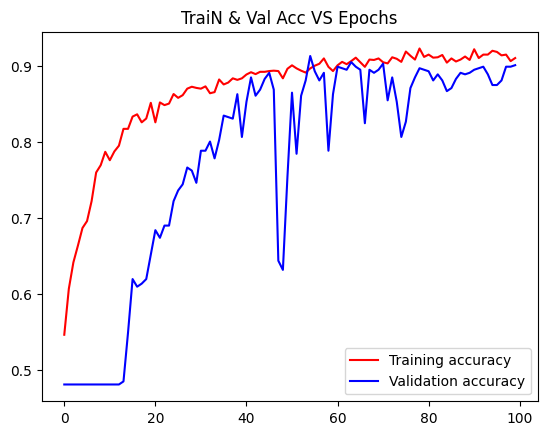

<Figure size 640x480 with 0 Axes>

In [21]:
epochs = range(len(acc))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('TraiN & Val Acc VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

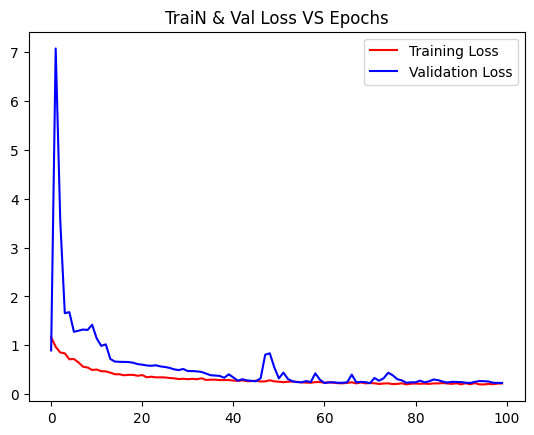

<Figure size 640x480 with 0 Axes>

In [22]:
epochs = range(len(acc))
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('TraiN & Val Loss VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

In [24]:
import os
print(os.getcwd())
print(os.listdir())


S:\CovCNN-WebApp\Dataset
['COVID', 'non-COVID', 'ResNet50_Model.keras']


In [25]:
model.load_weights("ResNet50_Model.keras")
score = model.evaluate(X_val, Y_val, verbose=1)
print('Test Loss:', score[0])
print('Test Accuracy:', score[1] * 100)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9034 - loss: 0.2246
Test Loss: 0.22459731996059418
Test Accuracy: 90.34205079078674


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


Text(0.5, 1.0, 'Confusion Matrix')

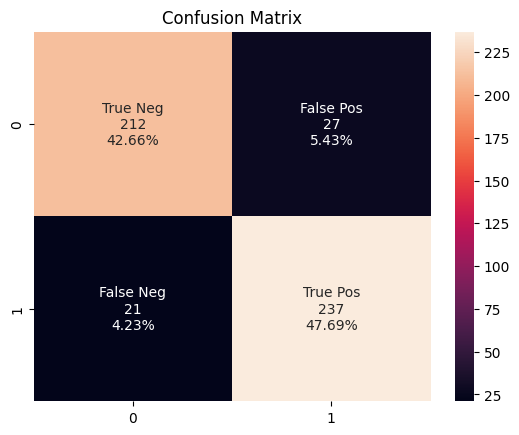

In [27]:
Y_pred = model.predict(X_val)
Y_predx = np.argmax(Y_pred, axis = -1)
Y_valx = np.argmax(Y_val, axis = -1)
cf_matrix = confusion_matrix(Y_valx, Y_predx)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf_matrix, annot = labels, fmt = '')
plt.title("Confusion Matrix")